# Gaussian Mean FIlter

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

## Signal denoising using Gaussian Mean Filter

In [6]:
# Creating signal
srate = 512  # Sampling rate [Hz]
t = np.arange(0, 3, 1/srate )
pnts = len(t)

# Noiseless signal 
signal = np.sin( 2 * np.pi * 2 * t)

# Creating a noise 
noise = 7 * np.random.randn(pnts)

# Adding noise on signal
noisySignal = signal + noise
noisySignal

array([-1.63631601, -0.76324021, -0.85632233, ..., -6.70633016,
       -2.90450455, -4.23429098], shape=(1536,))

In [7]:
pnts

1536

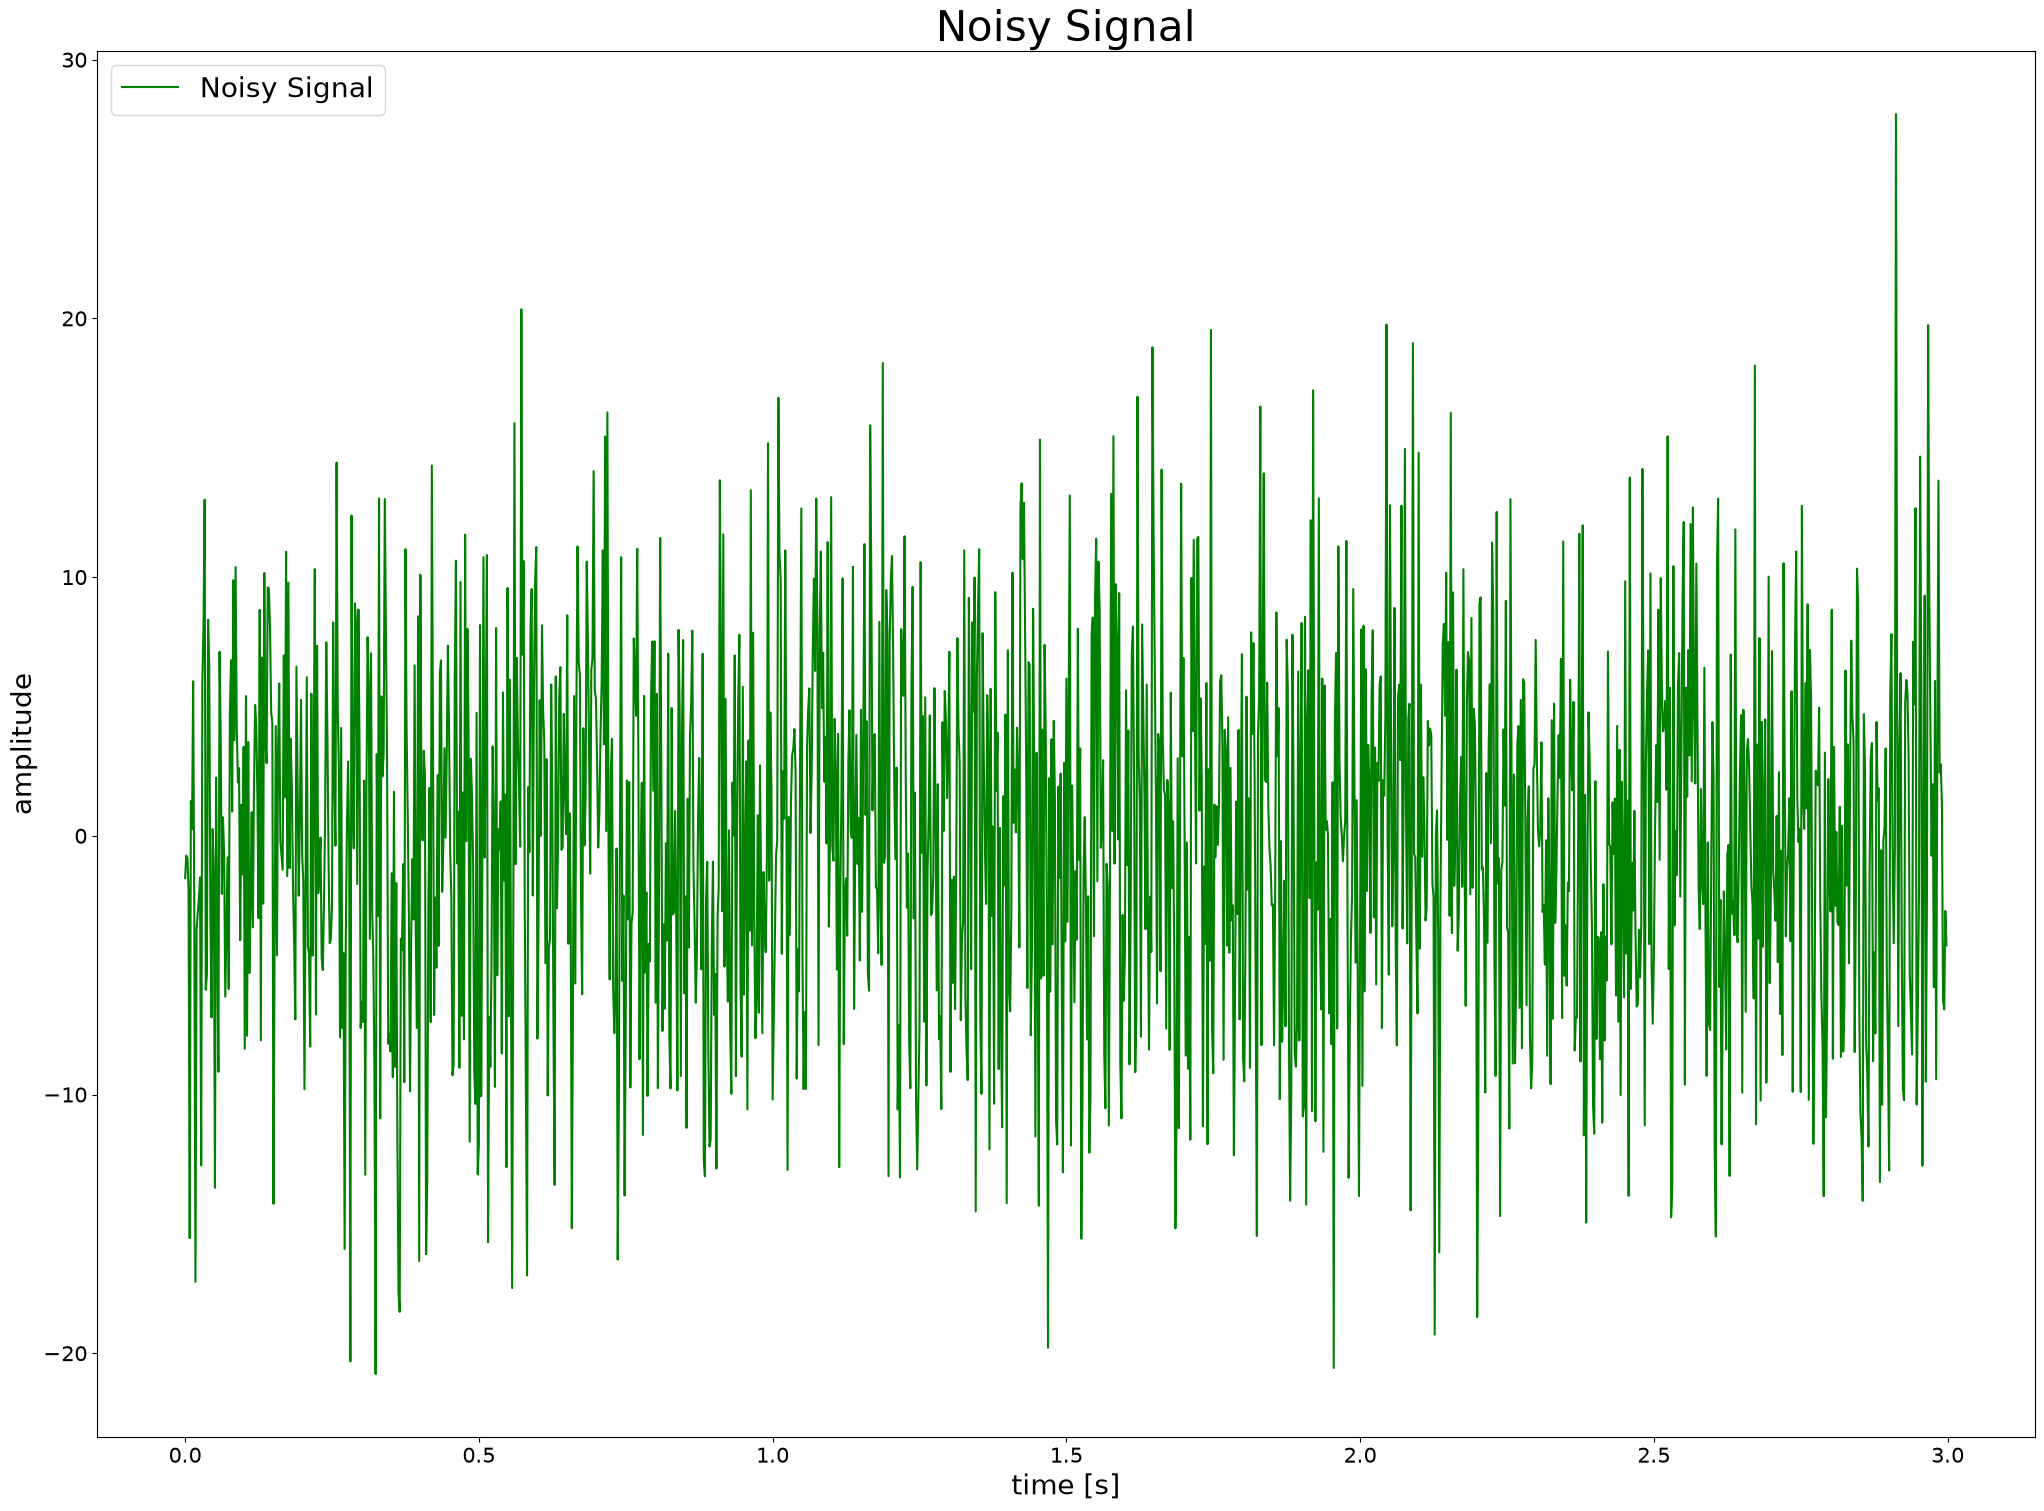

In [10]:
# Plotting

plt.figure(figsize=(25,18))
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t, noisySignal, 'g', label='Noisy Signal')
plt.title(label = 'Noisy Signal', fontsize = 30)
plt.xlabel('time [s]', fontsize = 20)
plt.ylabel('amplitude', fontsize = 20)
plt.legend(fontsize = 20)

plt.show()

## Generating Gaussian Filter

In [25]:
N = 100 
fwhm = 50 #ms - full width half maximum
Gtime = 1000 * np.arange(-N, N)/srate  # fwhm is in ms, so we need Gtime also in [ms]
Gfilter = np.exp( -(4 * np.log(2) * Gtime**2) / fwhm**2 )  # We using Gaussian Mean Filter pattern 
Gfilter = Gfilter/np.sum(Gfilter) # Normalizing the Gaussian FIlter



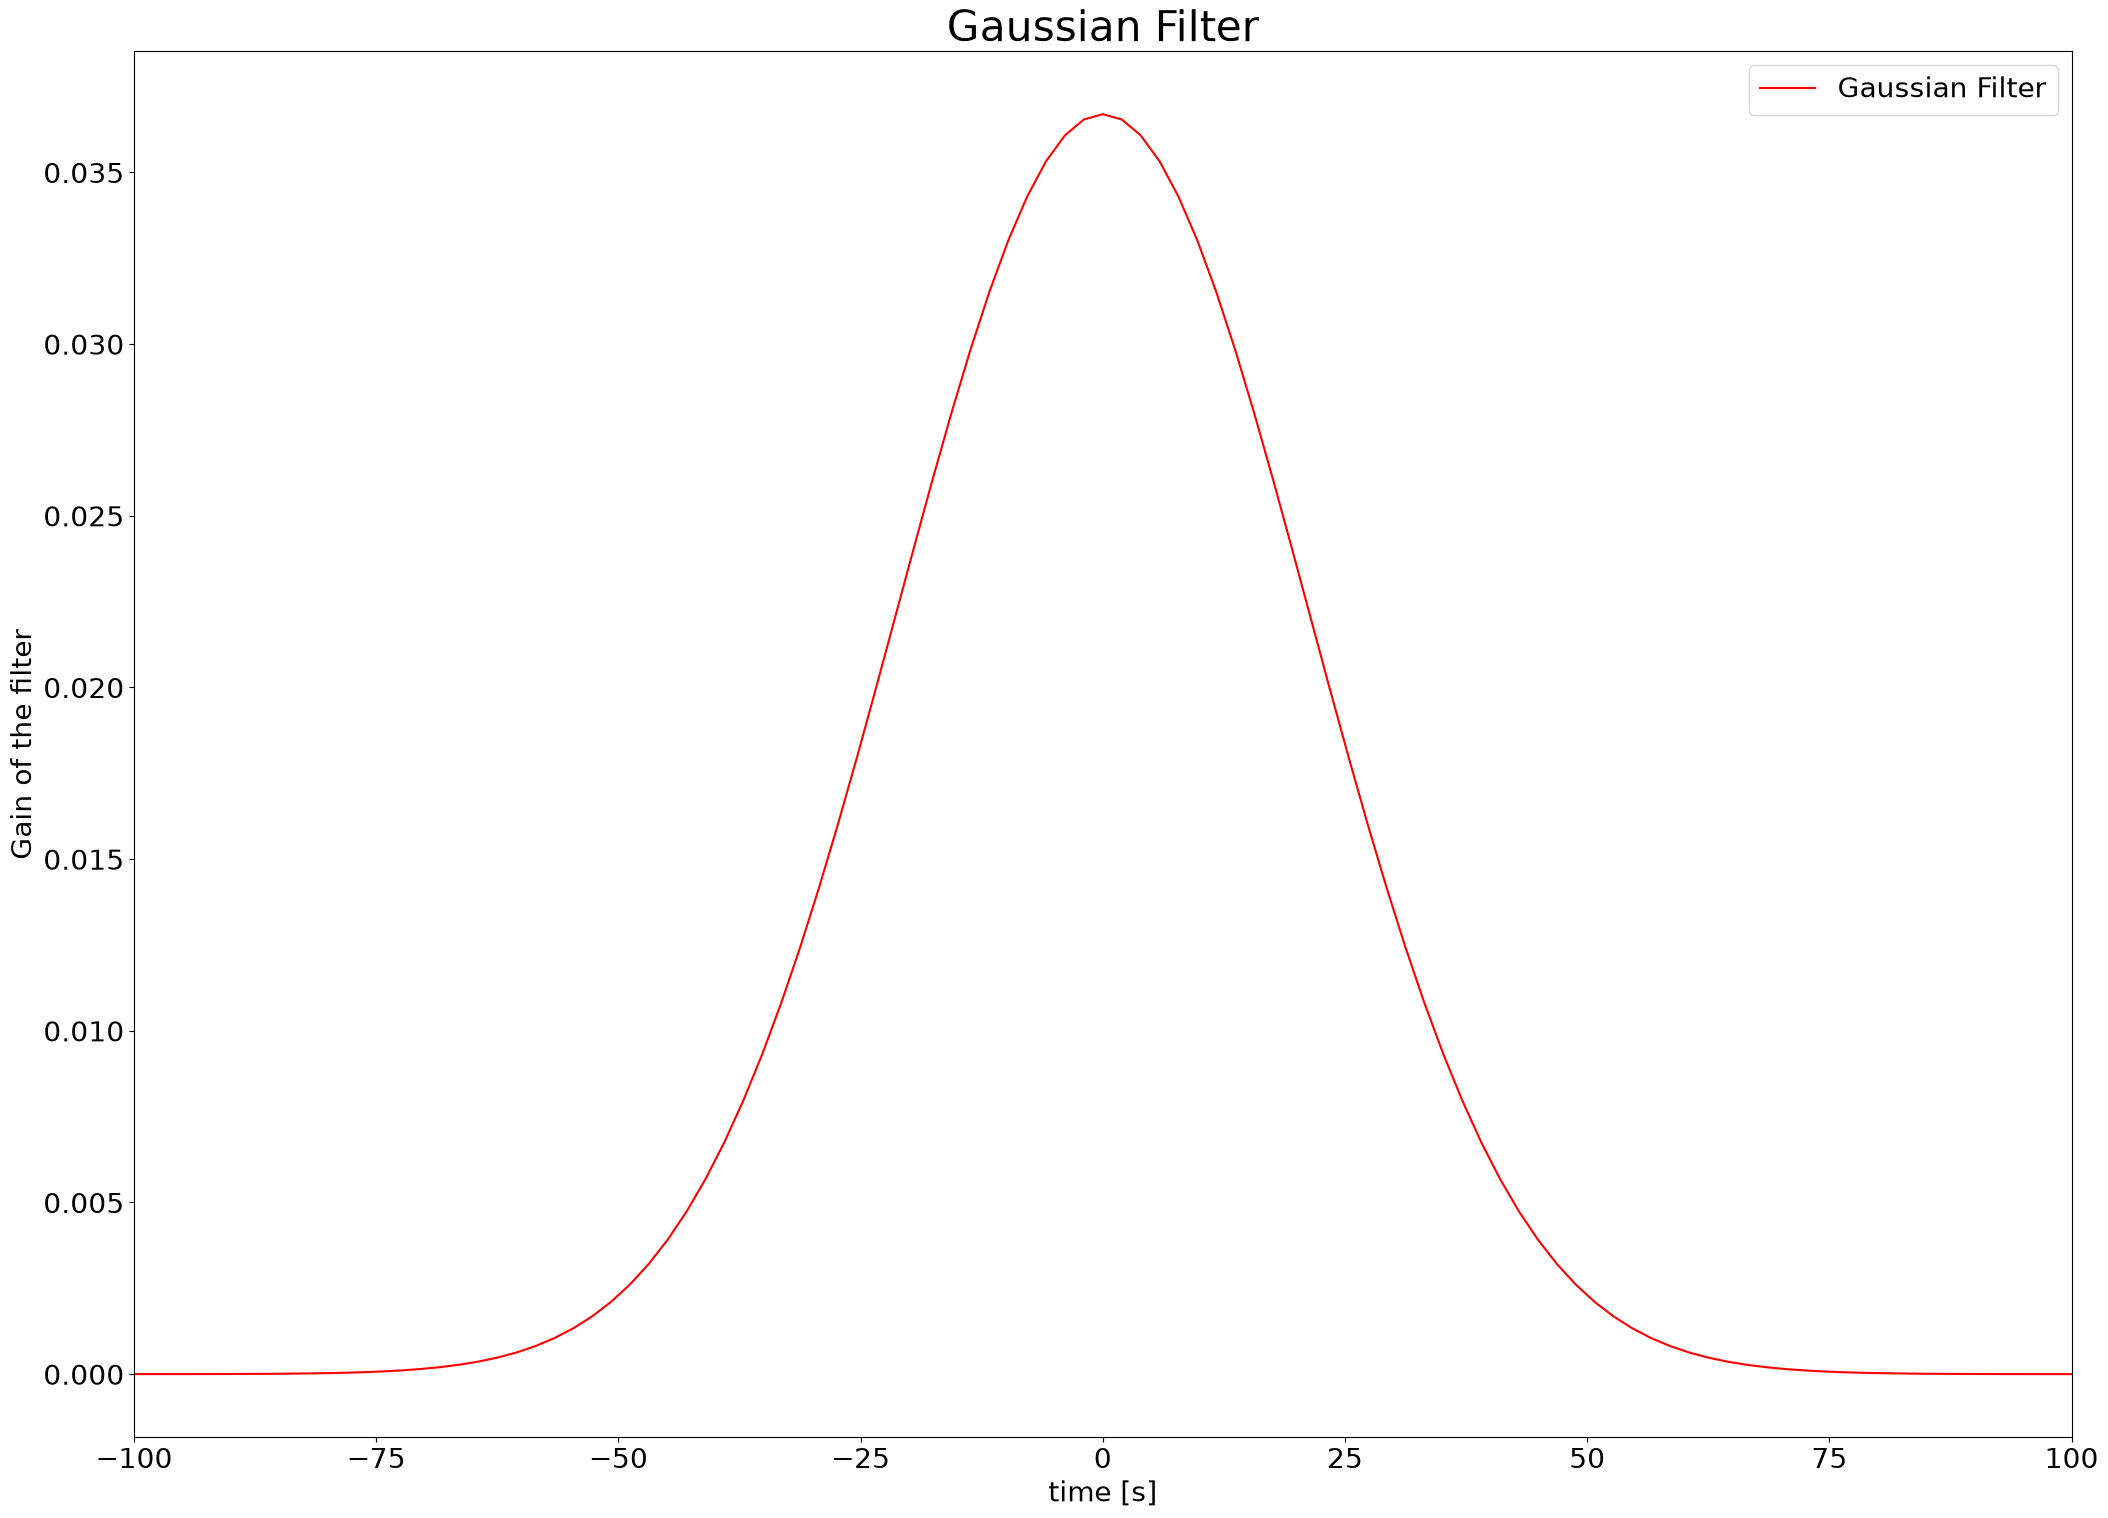

In [35]:
# Plotting 

plt.figure(figsize=(25,18))
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.plot(Gtime, Gfilter, 'r', label='Gaussian Filter')
plt.title(label = 'Gaussian Filter', fontsize = 30)
plt.xlabel('time [s]', fontsize = 20)
plt.ylabel('Gain of the filter', fontsize = 20)
plt.legend(fontsize = 20)
plt.xlim([-100, 100])

plt.show()

In [50]:
sig_filt = np.concatenate(( np.zeros(N), noisySignal, np.zeros(N )),  axis = 0)
K = len(noisySignal)
print(K)

timeIndex = np.concatenate ((np.arange(-N, 0), np.arange(0, K), np.arange(K, K+N)), axis = 0 ) 
timeFilter = timeIndex/srate

1536


In [51]:
print(len(sig_filt))
print(len(timeIndex))

1736
1736


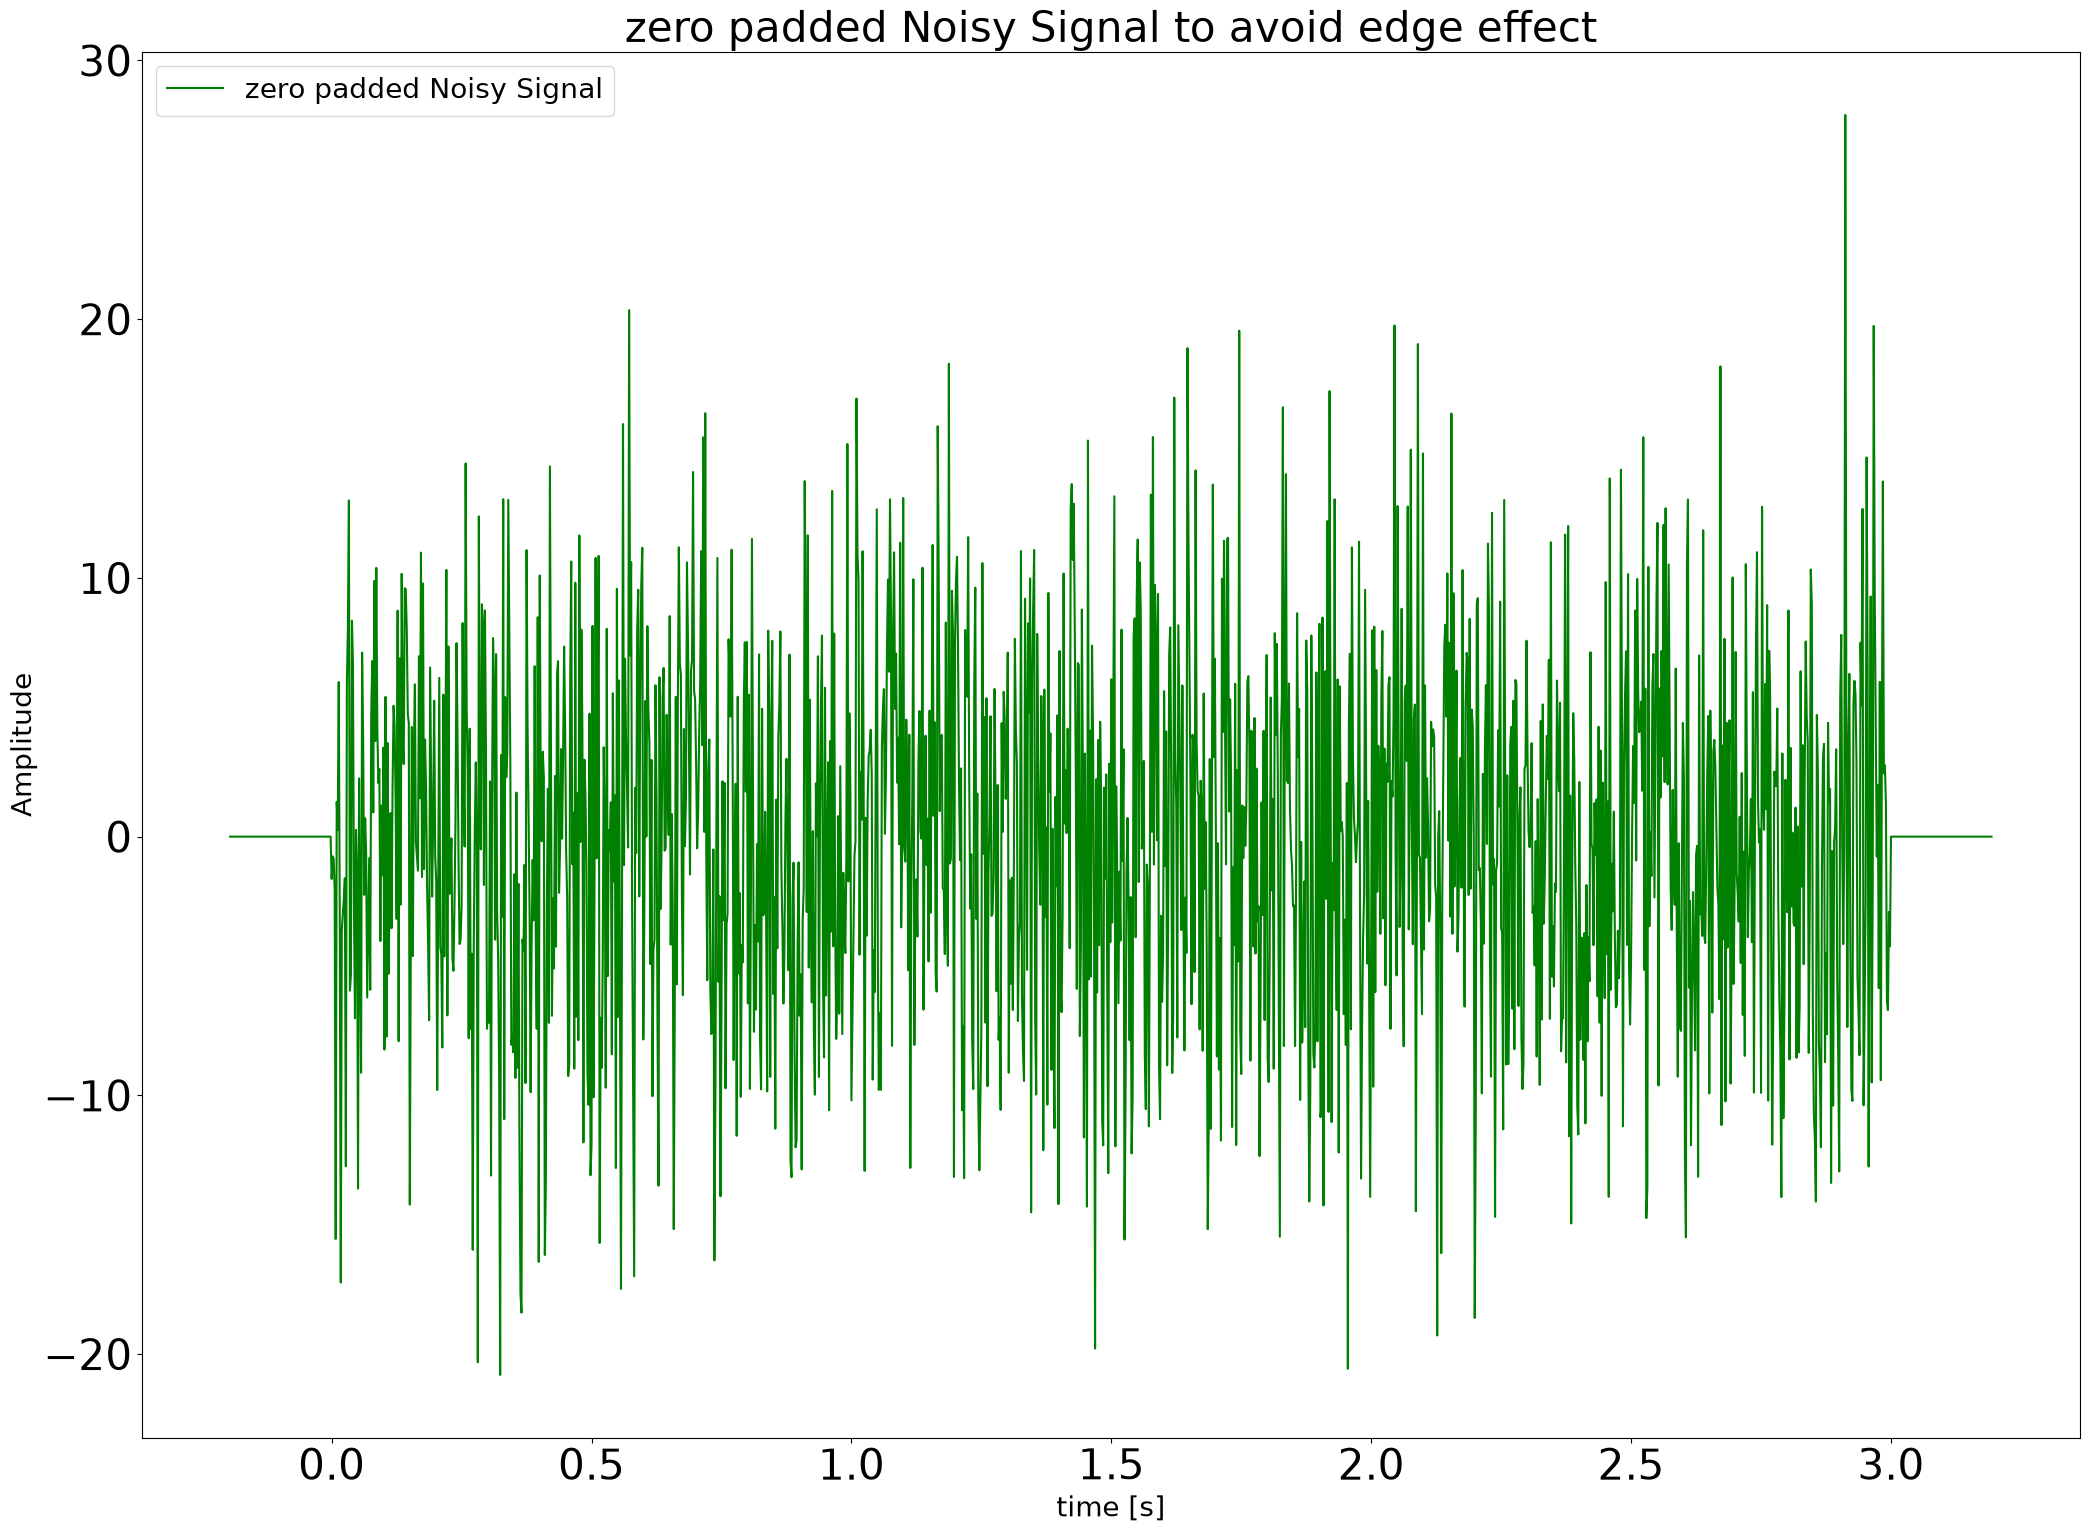

In [56]:
plt.figure(figsize=(25,18))
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.plot(timeFilter, sig_filt, 'g', label='zero padded Noisy Signal')
plt.title(label = 'zero padded Noisy Signal to avoid edge effect', fontsize = 30)
plt.xlabel('time [s]', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 20)
plt.show()


### USEFUL DOCUMENTATION 

In [15]:
### https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html

In [34]:
"""
from scipy.ndimage import gaussian_filter
filtered = gaussian_filter(noisySignal, sigma=5)
fig = plt.figure()
plt.gray()  # show the filtered result in grayscale
ax1 = fig.add_subplot(121)  # left side
ax2 = fig.add_subplot(122)  # right side
ascent = datasets.ascent()
result = gaussian_filter(ascent, sigma=5)
ax1.imshow(ascent)
ax2.imshow(result)
plt.show()
"""

'\nfrom scipy.ndimage import gaussian_filter\nfiltered = gaussian_filter(noisySignal, sigma=5)\nfig = plt.figure()\nplt.gray()  # show the filtered result in grayscale\nax1 = fig.add_subplot(121)  # left side\nax2 = fig.add_subplot(122)  # right side\nascent = datasets.ascent()\nresult = gaussian_filter(ascent, sigma=5)\nax1.imshow(ascent)\nax2.imshow(result)\nplt.show()\n'